In [37]:
# Librerias a importar
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

In [38]:
# Montar drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


#1. Carga y Exploración de Datos:
Cargar el dataset

In [39]:
# Importar DataFrame
path = '/content/drive/MyDrive/Colab Notebooks/Modelos Regresión/dataset/diabetes.csv'
data = pd.read_csv(path, sep=",")

Realizar una exploración inicial para entender la estructura del dataset

In [40]:
# Exploración de datos
print(data.head())
print(data.describe())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   

Identificar valores faltantes

In [41]:
# Hacemos copia del DataFrame
df=data.copy()

# Convertimos a minúsculas y quitamos espacios en blanco de las columnas
df.columns = df.columns.str.lower().str.strip()

# Convertimos a minúsculas y quitamos espacios en blanco de las columnas de tipo objeto
for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = df[col].str.lower().str.strip()

In [42]:
# Verificar por datos nulos
datos_null = df.isnull()
if datos_null.any().any():
    print("Cantidad de datos nulos por columna:\n", datos_null.sum())
else:
    print("No se encontró datos nulos")

No se encontró datos nulos


Verificar tipos de datos en columnas

In [43]:
print(df.info())
# Resultado: Tipos de Datos en columnas correctos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pregnancies               768 non-null    int64  
 1   glucose                   768 non-null    int64  
 2   bloodpressure             768 non-null    int64  
 3   skinthickness             768 non-null    int64  
 4   insulin                   768 non-null    int64  
 5   bmi                       768 non-null    float64
 6   diabetespedigreefunction  768 non-null    float64
 7   age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


Identificar valores únicos

In [44]:
# Verificamos valores únicos en las columas
for col in df.columns:
    print(f"\nDatos en la columa: '{col}':")
    print(df[col].unique())


Datos en la columa: 'pregnancies':
[ 6  1  8  0  5  3 10  2  4  7  9 11 13 15 17 12 14]

Datos en la columa: 'glucose':
[148  85 183  89 137 116  78 115 197 125 110 168 139 189 166 100 118 107
 103 126  99 196 119 143 147  97 145 117 109 158  88  92 122 138 102  90
 111 180 133 106 171 159 146  71 105 101 176 150  73 187  84  44 141 114
  95 129  79   0  62 131 112 113  74  83 136  80 123  81 134 142 144  93
 163 151  96 155  76 160 124 162 132 120 173 170 128 108 154  57 156 153
 188 152 104  87  75 179 130 194 181 135 184 140 177 164  91 165  86 193
 191 161 167  77 182 157 178  61  98 127  82  72 172  94 175 195  68 186
 198 121  67 174 199  56 169 149  65 190]

Datos en la columa: 'bloodpressure':
[ 72  66  64  40  74  50   0  70  96  92  80  60  84  30  88  90  94  76
  82  75  58  78  68 110  56  62  85  86  48  44  65 108  55 122  54  52
  98 104  95  46 102 100  61  24  38 106 114]

Datos en la columa: 'skinthickness':
[35 29  0 23 32 45 19 47 38 30 41 33 26 15 36 11 31 37 42 

Identificar inconsistencia en datos categóricos

In [45]:
# No se identificaron datos con inconsistencia

Identificar valores duplicados

In [46]:
# Buscar datos duplicados
datos_duplicados = df.duplicated()
if datos_duplicados.any():
    print("Cantidad de datos duplicados: ", datos_duplicados.sum())
else:
    print("No se encontró datos duplicados")

No se encontró datos duplicados


Identificar valores outliers

In [47]:
# Función para identificar valores outliers usando el método IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Identificar outliers en columna numéricas
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

# Excluir la columna 'outcome'
if 'outcome' in numerical_columns:
  numerical_columns.remove('outcome')

print("\nIdentificar outliers usando el método IQR:")
for col in numerical_columns:
    outliers = detect_outliers_iqr(df, col)
    if not outliers.empty:
        print(f"Outliers en columna '{col}':")
        print(outliers[[col]])
        print("-" * 30)


Identificar outliers usando el método IQR:
Outliers en columna 'pregnancies':
     pregnancies
88            15
159           17
298           14
455           14
------------------------------
Outliers en columna 'glucose':
     glucose
75         0
182        0
342        0
349        0
502        0
------------------------------
Outliers en columna 'bloodpressure':
     bloodpressure
7                0
15               0
18              30
43             110
49               0
60               0
78               0
81               0
84             108
106            122
125             30
172              0
177            110
193              0
222              0
261              0
266              0
269              0
300              0
332              0
336              0
347              0
357              0
362            108
426              0
430              0
435              0
453              0
468              0
484              0
494              0
522              0
5

#2. Limpieza y Preprocesamiento:

Eliminar columnas innecesarias

In [48]:
# No se consideró eliminar columnas del dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pregnancies               768 non-null    int64  
 1   glucose                   768 non-null    int64  
 2   bloodpressure             768 non-null    int64  
 3   skinthickness             768 non-null    int64  
 4   insulin                   768 non-null    int64  
 5   bmi                       768 non-null    float64
 6   diabetespedigreefunction  768 non-null    float64
 7   age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Manejar inconsistencia en datos categóricos

In [49]:
# No hay datos con inconsistencia en dataset

Eliminar duplicados

In [50]:
# No se encontraron datos duplicados

Manejo de valores faltantes

In [51]:
# No hay datos faltantes en el dataframe

Manejar valores outliers

In [52]:
# Función para reemplazar outliers con método IQR
def replace_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Reemplazar valores fuera de los límites
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

print("\nManejo de valores outliers usando el método IQR):")
for col in numerical_columns:
    df = replace_outliers_iqr(df, col)
    # Verificar si aún hay outliers después del reemplazo
    outliers_after = detect_outliers_iqr(df, col)
    if not outliers_after.empty:
        print(f"Advertencia: Aún existen outliers en la columna '{col}' después del reemplazo.")
    else:
        print(f"Outliers en columna '{col}' manejados exitosamente.")

# Verificar los cambios en los datos después de manejar outliers
print("\nVerificación de datos después de manejar outliers:")
print(df.describe())


Manejo de valores outliers usando el método IQR):
Outliers en columna 'pregnancies' manejados exitosamente.
Outliers en columna 'glucose' manejados exitosamente.
Outliers en columna 'bloodpressure' manejados exitosamente.
Outliers en columna 'skinthickness' manejados exitosamente.
Outliers en columna 'insulin' manejados exitosamente.
Outliers en columna 'bmi' manejados exitosamente.
Outliers en columna 'diabetespedigreefunction' manejados exitosamente.
Outliers en columna 'age' manejados exitosamente.

Verificación de datos después de manejar outliers:
       pregnancies     glucose  bloodpressure  skinthickness     insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.837240  121.136230      70.684896      20.511719   73.652669   
std       3.344157   31.187468      14.197239      15.844744   93.576029   
min       0.000000   37.125000      35.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000

##2. Exploración de Datos:
Crear visualizaciones univariadas y multivariadas

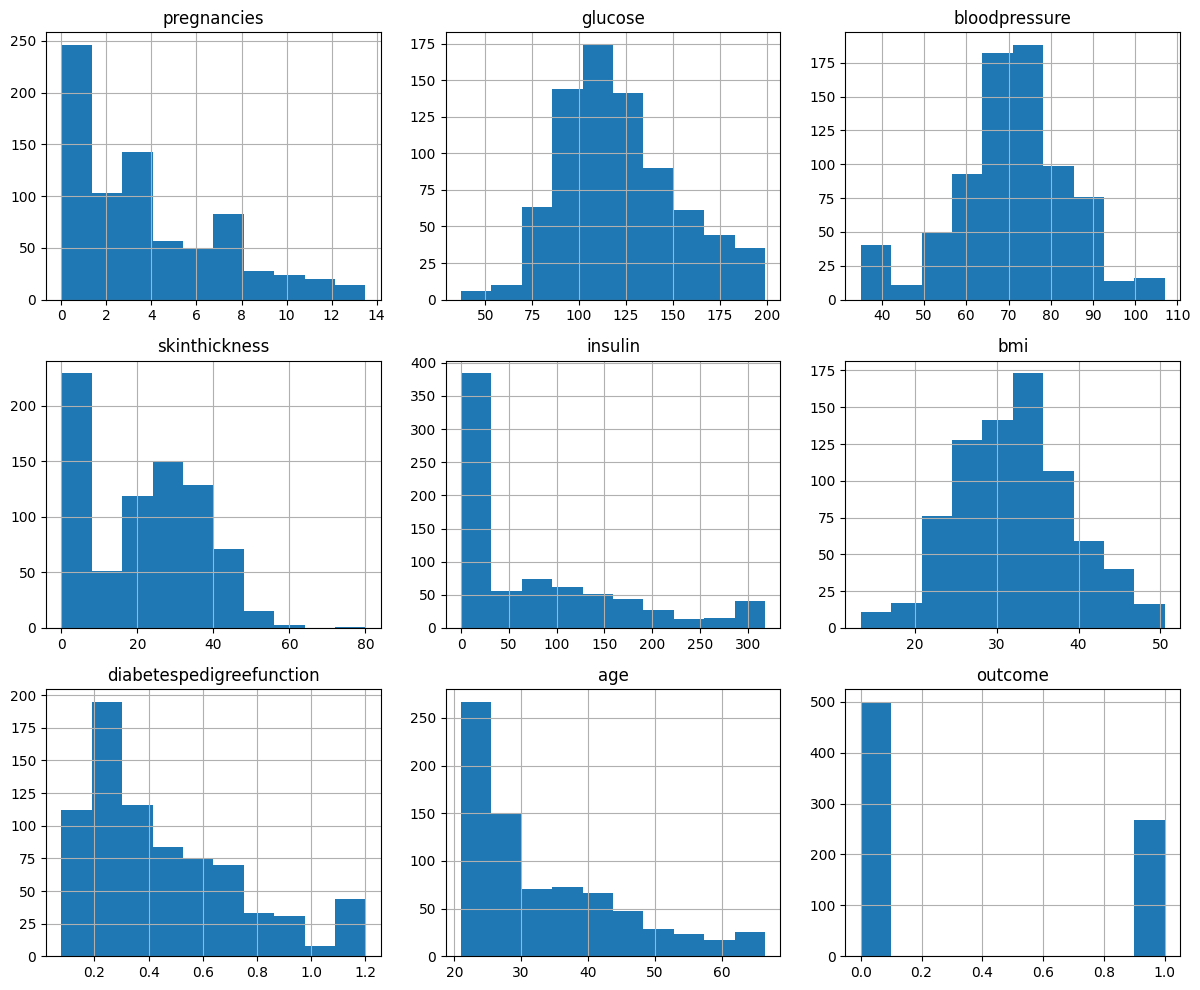

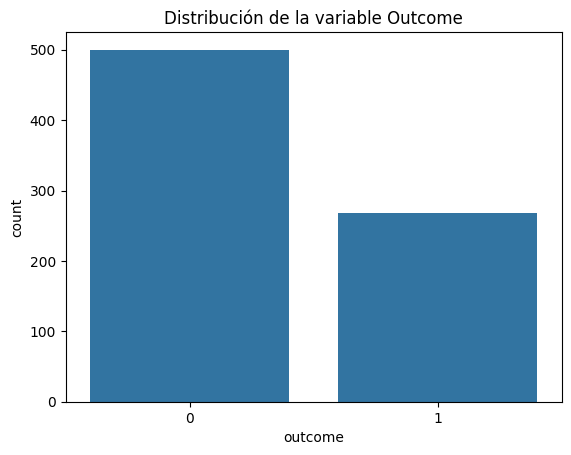

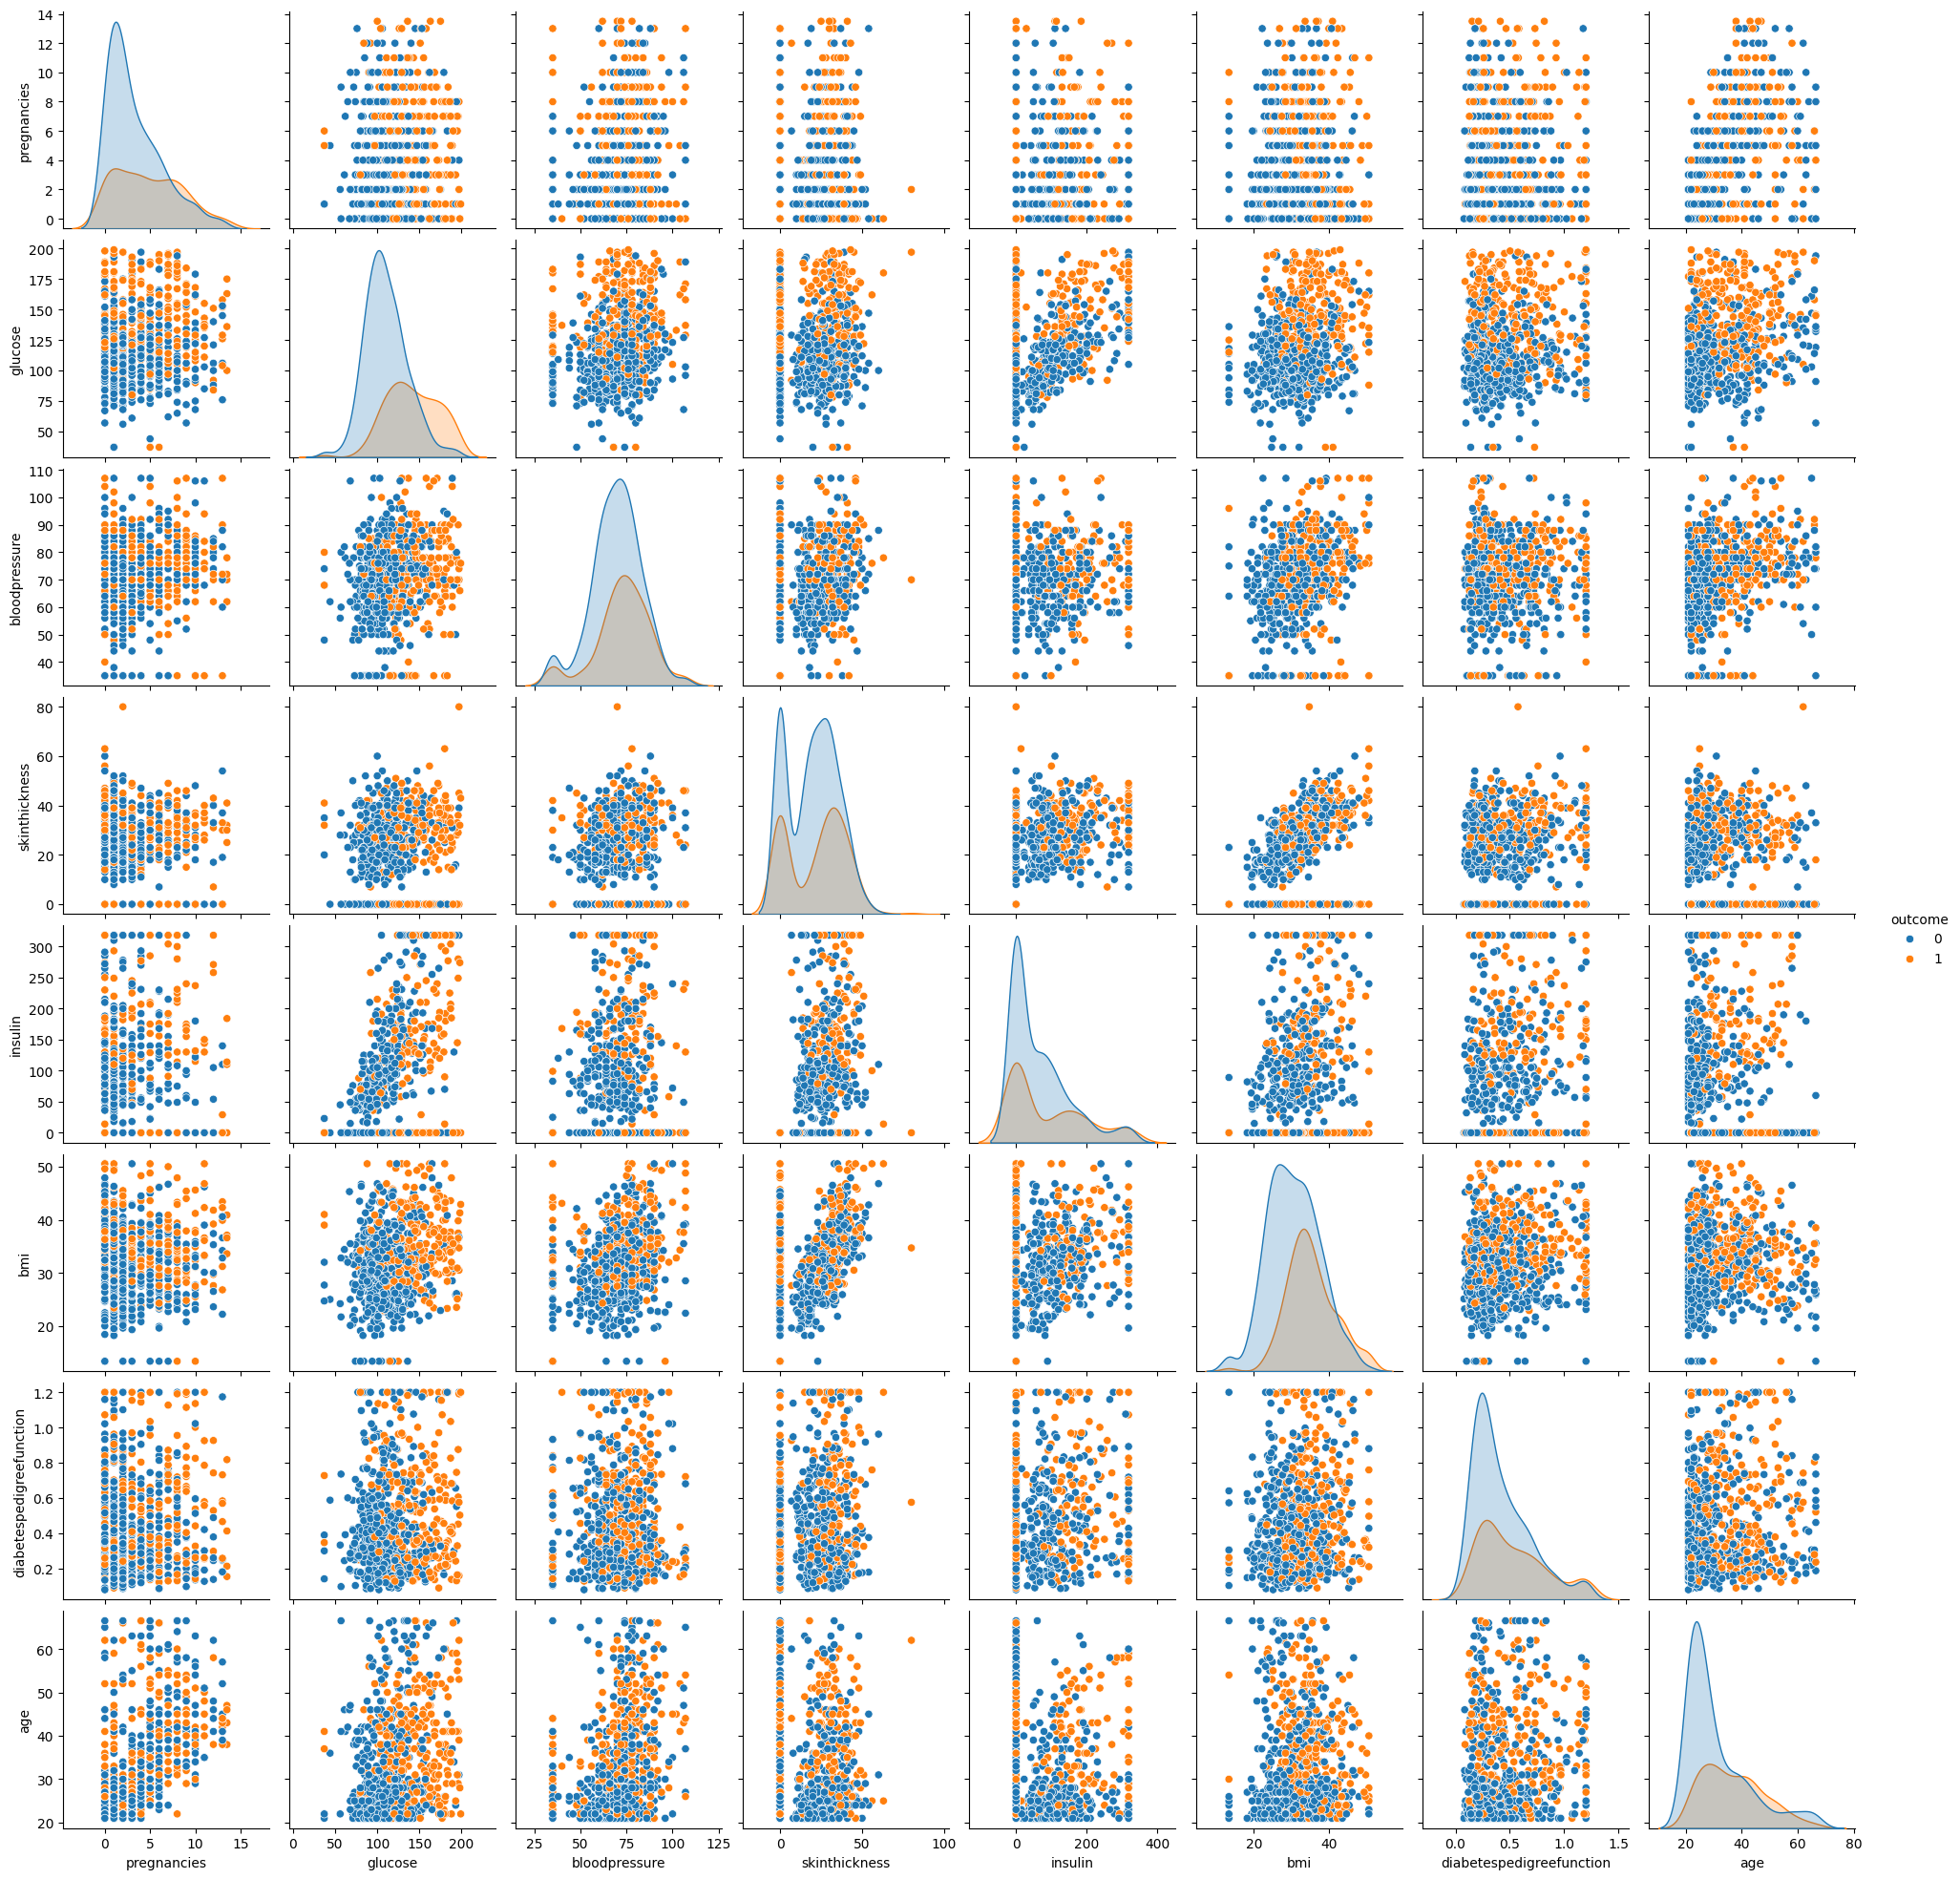

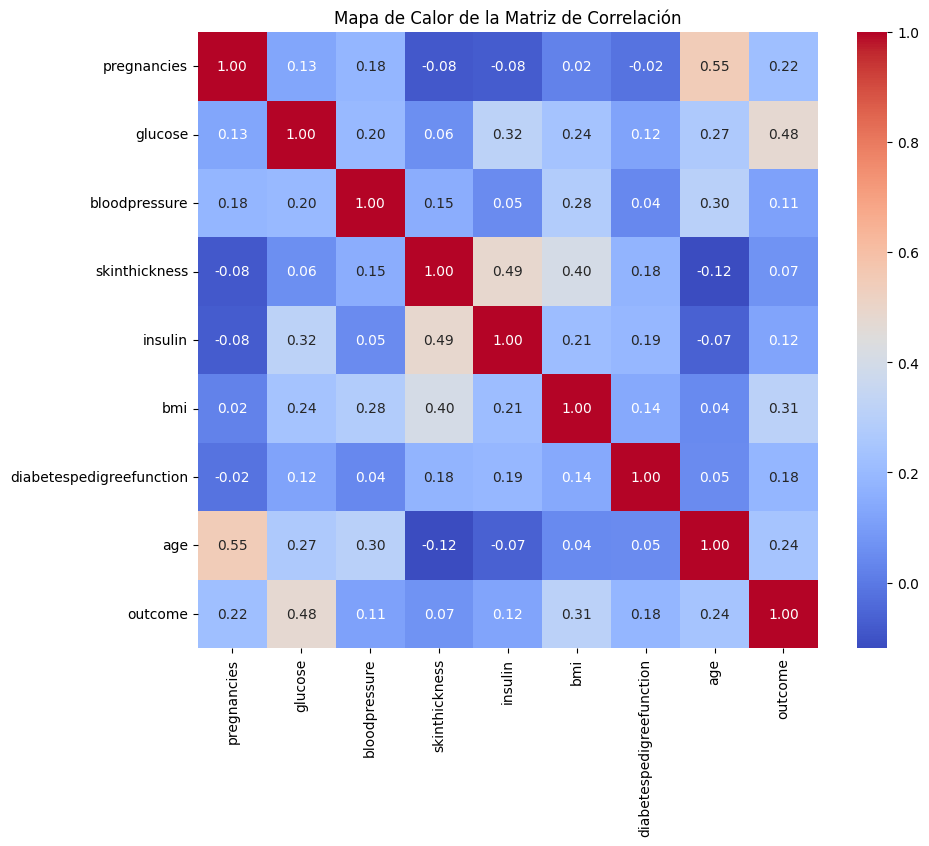

In [53]:
# Histogramas para variables numéricas
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

# Gráficos de barras para la variables 'outcome' categóricas
sns.countplot(x='outcome', data=df)
plt.title('Distribución de la variable Outcome')
plt.show()

# Diagramas de dispersión para relaciones entre pares de variables numéricas
sns.pairplot(df, hue='outcome', diag_kind='kde')
plt.show()

# Mapas de calor para la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()

Explicación de los gráficos

1.  **Histogramas para variables numéricas:**
    *   **Propósito:** Mostrar la distribución de cada variable numérica en el dataset.
    *   **Interpretación:** Cada histograma muestra la frecuencia de los valores dentro de diferentes rangos (bins) para una variable específica. Esto ayuda a entender la forma de la distribución de los datos (simétrica, sesgada, multimodal), identificar la dispersión y detectar posibles valores atípicos o patrones inusuales.

2.  **Gráfico de barras para la variable 'outcome':**
    *   **Propósito:** Visualizar la distribución de la variable categórica 'outcome', variable que indica la presencia o ausencia de diabetes.
    *   **Interpretación:** Este gráfico de barras muestra el número de instancias para cada categoría de 'outcome'. Permite ver si el dataset está equilibrado en términos de las clases de la variable objetivo, es decir, si hay un número similar de casos positivos y negativos o si existe un desequilibrio de clases.

3.  **Diagramas de dispersión para relaciones entre pares de variables numéricas:**
    *   **Propósito:** Explorar las relaciones de correlación entre pares de variables numéricas.
    *   **Interpretación:** Este gráfico matricial muestra un diagrama de dispersión para cada par de variables numéricas. El color de los puntos en los diagramas de dispersión está diferenciado por la variable 'outcome'. En la diagonal, en lugar de diagramas de dispersión, se muestran gráficos de densidad (KDE) que también muestran la distribución de cada variable, separada por la categoría de 'outcome'. Ayuda a identificar si existe una relación lineal o no lineal entre variables y si esta relación difiere según el resultado ('outcome').

4.  **Mapa de calor para la matriz de correlación:**
    *   **Propósito:** Visualizar la fuerza y dirección de la correlación lineal entre todas las pares de variables numéricas.
    *   **Interpretación:** La matriz de correlación se muestra como un mapa de calor donde el color de cada celda indica el coeficiente de correlación entre dos variables. Los valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente, mientras que los valores cercanos a 0 indican una baja correlación. Los números dentro de las celdas (`annot=True`) muestran el valor exacto del coeficiente de correlación. Este gráfico es útil para identificar variables altamente correlacionadas, lo cual puede ser importante para la selección de características o para entender las interrelaciones en los datos.

Calcular estadísticas descriptivas

In [54]:
print("\nEstadísticas descriptivas detalladas por columna:")
print("\nResumen general de estadísticas descriptivas:")
print(df.describe(include='all'))


Estadísticas descriptivas detalladas por columna:

Resumen general de estadísticas descriptivas:
       pregnancies     glucose  bloodpressure  skinthickness     insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.837240  121.136230      70.684896      20.511719   73.652669   
std       3.344157   31.187468      14.197239      15.844744   93.576029   
min       0.000000   37.125000      35.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      13.500000  199.000000     107.000000      80.000000  318.125000   

              bmi  diabetespedigreefunction         age     outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.125065                  0.458914   33.199870    0.348958  
std    

#3. Implementación de Modelos:

Uso de ColumnTransformer y Pipeline

In [55]:
# Cargar el conjunto de datos
X = df.drop('outcome', axis=1)
y = df['outcome']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Seleccionar columnas numéricas para escalar
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

# Identificar las columnas categóricas
# En este dataset solo hay columnas numéricas, así que se omiten

# Crear transformadores para cada subconjunto de columnas
# Escalar las características numéricas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Se omite realizar transformaciones para las características categóricas, por no existir en el dataframe


# Crear un ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
],
    remainder='passthrough'
)

## Modelo Random Forest

Mejores hiperparámetros para Random Forest: {'classifier__bootstrap': True, 'classifier__class_weight': None, 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}

Métricas de evaluación para el mejor modelo Random Forest:
Accuracy: 0.7532
Precision: 0.6491
Recall: 0.6727
F1-score: 0.6607
ROC-AUC: 0.8305

Matriz de Confusión:
[[79 20]
 [18 37]]


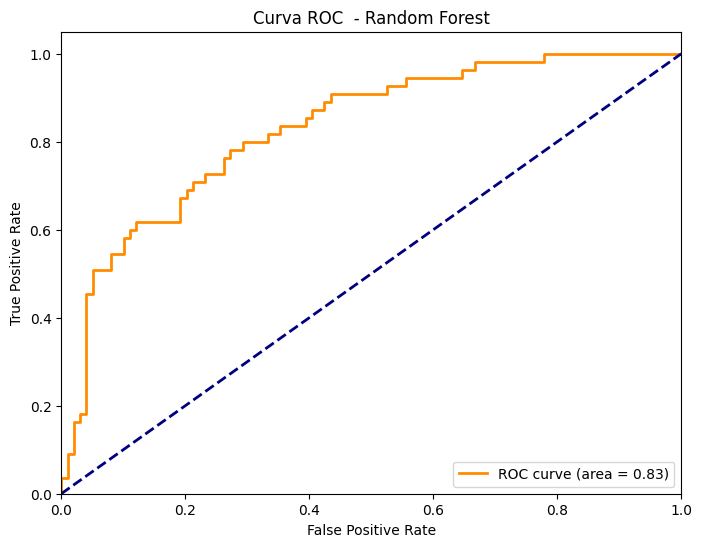

In [56]:
# Pipeline y preprocesamiento del modelo Random Forest
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', RandomForestClassifier(random_state=42))])

# Definir la grilla de hiperparámetros a tunear
param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],  # Número de árboles en el bosque
    'classifier__max_depth': [None, 10, 20, 30], # Profundidad máxima de los árboles
    'classifier__min_samples_split': [2, 5, 10], # Número mínimo de muestras requeridas para dividir un nodo interno
    'classifier__min_samples_leaf': [1, 2, 4],   # Número mínimo de muestras requeridas para ser una hoja
    'classifier__bootstrap': [True, False],     # Método para muestrear puntos de datos (con o sin reemplazo)
    'classifier__class_weight': [None, 'balanced', 'balanced_subsample'] # Pesos asociados a las clases
}

# Configurar GridSearchCV para encontrar la mejor combinación de hiperparámetros
grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)

# Entrenar el modelo con la búsqueda de hiperparámetros
grid_search_rf.fit(X_train, y_train)

# Imprimir los mejores hiperparámetros encontrados
print("Mejores hiperparámetros para Random Forest:", grid_search_rf.best_params_)

# Evaluar el mejor modelo en el conjunto de prueba
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)
y_pred_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

# Calcular métricas de evaluación
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

print("\nMétricas de evaluación para el mejor modelo Random Forest:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nMatriz de Confusión:")
print(cm_rf)

# Gráfico de la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC  - Random Forest')
plt.legend(loc="lower right")
plt.show()

##Modelo de XGBoost

Mejores hiperparámetros para XGBoost: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50, 'classifier__reg_alpha': 0.5, 'classifier__reg_lambda': 0.1, 'classifier__subsample': 0.8}

Métricas de evaluación para el mejor modelo XGBoost:
Accuracy: 0.7727
Precision: 0.6724
Recall: 0.7091
F1-score: 0.6903
ROC-AUC: 0.8112

Matriz de Confusión:
[[80 19]
 [16 39]]


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [00:47:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


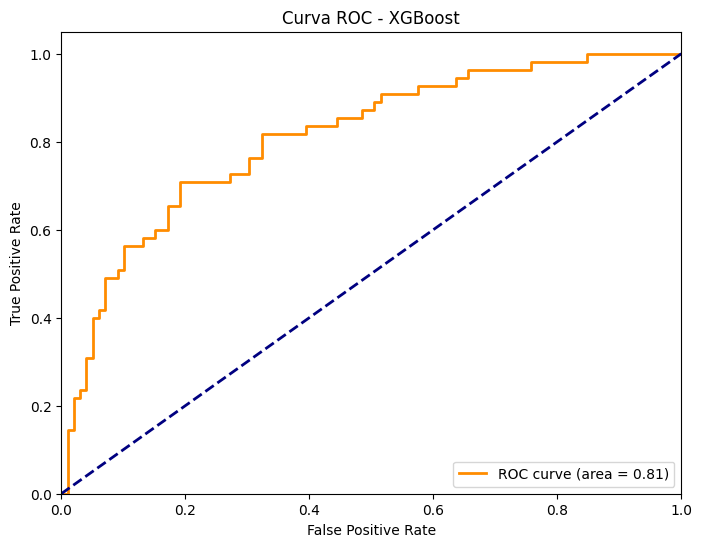

In [57]:
# Pipeline y preprocesamiento del modelo XGBoost
pipeline_xgb = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))])

# Definir los hiperparámetros a tunear para XGBoost
param_grid_xgb = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__reg_alpha': [0, 0.1, 0.5],
    'classifier__reg_lambda': [0, 0.1, 0.5]
}

# Configurar la búsqueda de cuadrícula con validación cruzada
grid_search_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)

# Entrenar el modelo con la búsqueda de hiperparámetros
grid_search_xgb.fit(X_train, y_train)

# Imprimir los mejores hiperparámetros encontrados
print("Mejores hiperparámetros para XGBoost:", grid_search_xgb.best_params_)

# Evaluar el mejor modelo en el conjunto de prueba
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test)
y_pred_proba_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# Calcular métricas de evaluación
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

print("\nMétricas de evaluación para el mejor modelo XGBoost:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-score: {f1_xgb:.4f}")
print(f"ROC-AUC: {roc_auc_xgb:.4f}")

# Matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nMatriz de Confusión:")
print(cm_xgb)

# Gráfico de la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_xgb)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - XGBoost')
plt.legend(loc="lower right")
plt.show()

Comparación de Rendimiento


Comparación de Métricas de Rendimiento:
      Metric  Random Forest   XGBoost
0   Accuracy       0.753247  0.772727
1  Precision       0.649123  0.672414
2     Recall       0.672727  0.709091
3   F1-score       0.660714  0.690265
4    ROC-AUC       0.830487  0.811203

Discusión sobre la adecuación del modelo:
Basándonos en la métrica de Accuracy, el modelo XGBoost tuvo un mejor rendimiento.

Análisis más detallado:
El modelo Random Forest parece ser ligeramente mejor en la discriminación entre clases positivas y negativas, mayor ROC-AUC.

Considerando las matrices de confusión:
Random Forest Confusion Matrix:
 [[79 20]
 [18 37]]

XGBoost Confusion Matrix:
 [[80 19]
 [16 39]]

Observando las matrices de confusión, podemos analizar los Falsos Positivos y Falsos Negativos de cada modelo.
Un modelo con menos Falsos Negativos, alta recall, es deseable si el costo de no identificar un caso positivo es alto.
Un modelo con menos Falsos Positivos, alta precision, es deseable si el costo de ide

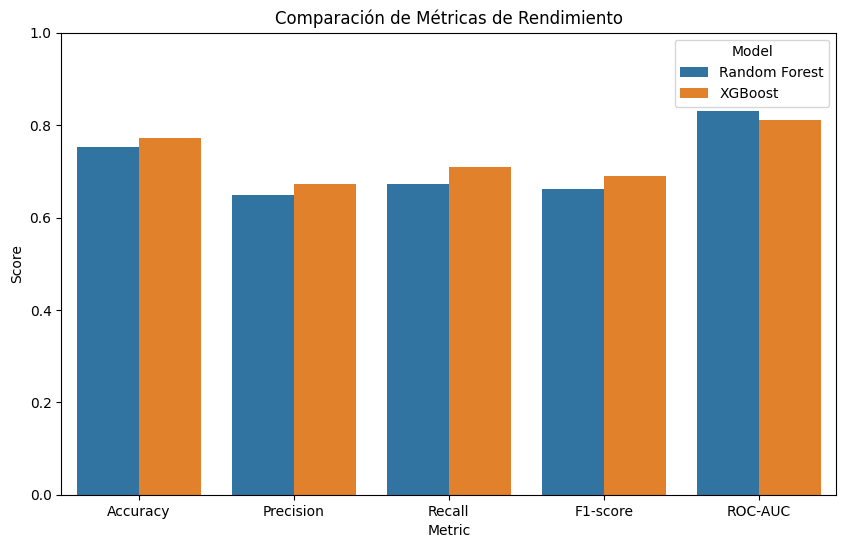

In [58]:
# Construir un DataFrame con las métricas para la comparación
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Random Forest': [accuracy_rf, precision_rf, recall_rf, f1_rf, roc_auc_rf],
    'XGBoost': [accuracy_xgb, precision_xgb, recall_xgb, f1_xgb, roc_auc_xgb]
})

print("\nComparación de Métricas de Rendimiento:")
print(comparison_df)

# Discusión
print("\nDiscusión sobre la adecuación del modelo:")
if accuracy_xgb > accuracy_rf:
    print("Basándonos en la métrica de Accuracy, el modelo XGBoost tuvo un mejor rendimiento.")
elif accuracy_rf > accuracy_xgb:
    print("Basándonos en la métrica de Accuracy, el modelo Random Forest tuvo un mejor rendimiento.")
else:
    print("Ambos modelos tuvieron un rendimiento similar en términos de Accuracy.")

print("\nAnálisis más detallado:")
if roc_auc_xgb > roc_auc_rf:
    print("El modelo XGBoost parece ser ligeramente mejor en la discriminación entre clases positivas y negativas, mayor ROC-AUC.")
elif roc_auc_rf > roc_auc_xgb:
    print("El modelo Random Forest parece ser ligeramente mejor en la discriminación entre clases positivas y negativas, mayor ROC-AUC.")
else:
    print("Ambos modelos tuvieron un rendimiento similar en términos de ROC-AUC.")

print("\nConsiderando las matrices de confusión:")
print("Random Forest Confusion Matrix:\n", cm_rf)
print("\nXGBoost Confusion Matrix:\n", cm_xgb)
print("\nObservando las matrices de confusión, podemos analizar los Falsos Positivos y Falsos Negativos de cada modelo.")
print("Un modelo con menos Falsos Negativos, alta recall, es deseable si el costo de no identificar un caso positivo es alto.")
print("Un modelo con menos Falsos Positivos, alta precision, es deseable si el costo de identificar erróneamente un caso negativo como positivo es alto.")

if recall_xgb > recall_rf:
    print(f"XGBoost tiene un Recall más alto ({recall_xgb:.4f} vs {recall_rf:.4f}), lo que significa que identifica una mayor proporción de casos positivos reales.")
elif recall_rf > recall_xgb:
    print(f"Random Forest tiene un Recall más alto ({recall_rf:.4f} vs {recall_xgb:.4f}), lo que significa que identifica una mayor proporción de casos positivos reales.")
else:
    print("Ambos modelos tienen Recall similar.")

if precision_xgb > precision_rf:
    print(f"XGBoost tiene una Precision más alta ({precision_xgb:.4f} vs {precision_rf:.4f}), lo que significa que, cuando predice un caso positivo, es más probable que sea correcto.")
elif precision_rf > precision_xgb:
     print(f"Random Forest tiene una Precision más alta ({precision_rf:.4f} vs {precision_xgb:.4f}), lo que significa que, cuando predice un caso positivo, es más probable que sea correcto.")
else:
    print("Ambos modelos tienen Precision similar.")

print("\nConclusión:")
print("Ambos modelos, Random Forest y XGBoost, han mostrado un buen rendimiento en este dataset.")
print("La elección del modelo más adecuado depende de las prioridades del problema.")
print("Si el principal objetivo es minimizar los Falsos Negativos, identificar tantos casos de diabetes como sea posible, se debería priorizar el Recall.")
print("Si el principal objetivo es minimizar los Falsos Positivos, evitar diagnósticos incorrectos de diabetes, se debería priorizar la Precision.")
print("En general, XGBoost a menudo ofrece un rendimiento ligeramente superior en muchos conjuntos de datos tabulares debido a su naturaleza de boosting y regularización efectiva.")
print("Para este dataset particular, al observar las métricas, XGBoost parece tener un rendimiento general marginalmente mejor, mayor Accuracy, ROC-AUC y F1-score, aunque el rendimiento puede variar con diferentes semillas aleatorias o configuraciones de validación cruzada.")
print("Si el tiempo de entrenamiento o la interpretabilidad del modelo fueran factores importantes, Random Forest podría ser una alternativa atractiva.")

# Comparación usando gráfico bar plot
comparison_df_melted = comparison_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_df_melted)
plt.title('Comparación de Métricas de Rendimiento')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()